In [2]:
import json
import pandas as pd
import numpy as np

In [3]:
df_raw = pd.read_csv("storage/nlsy_unclean.csv")
df_raw.head(10)

,CPUBID,MPUBID,CRACE,CSEX,CYRB,DADHM1986,DADHM1988,DADHM1990,DADHM1992,DADHM1994,...,MS-HOME-A09.4,MS-HOME-A10A.4,MS-HOME-A10B.4,MS-HOME-A11.4,MS-HOME-A16.4,MS-HOME-A17A.4,MS-HOME-A18.4,Q13-10B,Q13-16,VERSION_R29
0,201,2,3,2,1993,-7,-7,-7,-7,1,...,-7,-7,-7,-7,-7,-7,-7,-7,-7,532
1,202,2,3,2,1994,-7,-7,-7,-7,-7,...,-7,-7,-7,-7,-7,-7,-7,-7,-7,532
2,301,3,3,2,1981,1,1,1,1,1,...,-7,-7,-7,-7,-7,-7,-7,-7,-7,532
3,302,3,3,2,1983,1,1,1,1,1,...,-7,-7,-7,-7,-7,-7,-7,-7,-7,532
4,303,3,3,2,1986,-7,1,1,1,1,...,-7,-7,-7,-7,-7,-7,-7,-7,-7,532
5,401,4,3,1,1980,0,0,0,0,-7,...,-7,-7,-7,-7,-7,-7,-7,-7,-7,532
6,403,4,3,2,1997,-7,-7,-7,-7,-7,...,-7,-7,-7,-7,-7,-7,-7,-7,-7,532
7,801,8,3,2,1976,1,0,0,0,-7,...,-7,-7,-7,-7,-7,-7,-7,-7,-7,532
8,802,8,3,1,1979,1,0,0,0,0,...,-7,-7,-7,-7,-7,-7,-7,-7,-7,532
9,803,8,3,2,1982,1,0,0,0,0,...,-7,-7,-7,-7,-7,-7,-7,-7,-7,532


In [4]:
df_piat = pd.read_csv("storage/nlsy_piat_scores.csv")
df_piat.head(10)

,CPUBID,MPUBID,CRACE,CSEX,CMOB,CYRB,CS861670,MATH1986,MATHP1986,MATHZ1986,...,COMPZ2012,MATH2014,MATHP2014,MATHZ2014,RECOG2014,RECOGZ2014,RECOGP2014,COMP2014,COMPP2014,COMPZ2014
0,201,2,3,2,3,1993,-7,-7,-7,-7,...,-7,-7,-7,-7,-7,-7,-7,-7,-7,-7
1,202,2,3,2,11,1994,-7,-7,-7,-7,...,-7,-7,-7,-7,-7,-7,-7,-7,-7,-7
2,301,3,3,2,6,1981,-7,-7,-7,-7,...,-7,-7,-7,-7,-7,-7,-7,-7,-7,-7
3,302,3,3,2,10,1983,-7,-7,-7,-7,...,-7,-7,-7,-7,-7,-7,-7,-7,-7,-7
4,303,3,3,2,4,1986,-7,-7,-7,-7,...,-7,-7,-7,-7,-7,-7,-7,-7,-7,-7
5,401,4,3,1,8,1980,-7,-7,-7,-7,...,-7,-7,-7,-7,-7,-7,-7,-7,-7,-7
6,403,4,3,2,3,1997,-7,-7,-7,-7,...,-7,-7,-7,-7,-7,-7,-7,-7,-7,-7
7,801,8,3,2,3,1976,48,48,71,108,...,-7,-7,-7,-7,-7,-7,-7,-7,-7,-7
8,802,8,3,1,5,1979,38,41,95,125,...,-7,-7,-7,-7,-7,-7,-7,-7,-7,-7
9,803,8,3,2,9,1982,-7,-7,-7,-7,...,-7,-7,-7,-7,-7,-7,-7,-7,-7,-7


In [5]:
print(df_piat.columns.tolist())

['CPUBID', 'MPUBID', 'CRACE', 'CSEX', 'CMOB', 'CYRB', 'CS861670', 'MATH1986', 'MATHP1986', 'MATHZ1986', 'RECOG1986', 'RECOGP1986', 'RECOGZ1986', 'COMP1986', 'COMPP1986', 'COMPZ1986', 'MATH1988', 'MATHP1988', 'MATHZ1988', 'RECOG1988', 'RECOGP1988', 'RECOGZ1988', 'COMP1988', 'COMPP1988', 'COMPZ1988', 'MATH1990', 'MATHP1990', 'MATHZ1990', 'RECOG1990', 'RECOGP1990', 'RECOGZ1990', 'COMP1990', 'COMPP1990', 'COMPZ1990', 'CS924119', 'CS924123', 'CS924569', 'MATH1992', 'MATHP1992', 'MATHZ1992', 'RECOG1992', 'RECOGP1992', 'RECOGZ1992', 'COMP1992', 'COMPP1992', 'COMPZ1992', 'MATH1994', 'MATHP1994', 'MATHZ1994', 'RECOG1994', 'RECOGP1994', 'RECOGZ1994', 'COMP1994', 'COMPP1994', 'COMPZ1994', 'MATH1996', 'MATHP1996', 'MATHZ1996', 'RECOG1996', 'RECOGP1996', 'RECOGZ1996', 'COMP1996', 'COMPP1996', 'COMPZ1996', 'MATH1998', 'MATHP1998', 'MATHZ1998', 'RECOG1998', 'RECOGP1998', 'RECOGZ1998', 'COMP1998', 'COMPP1998', 'COMPZ1998', 'MATH2000', 'MATHP2000', 'MATHZ2000', 'RECOG2000', 'RECOGZ2000', 'RECOGP2000', 

In [6]:
# reshape PIAT data from wide to long format
id_vars = ['CPUBID', 'MPUBID', 'CRACE', 'CSEX', 'CMOB', 'CYRB']

#vars
math_vars = [col for col in df_piat.columns if col.startswith('MATH') and\
               not col.startswith('MATHZ') and not col.startswith('MATHP')]
mathz_vars = [col for col in df_piat.columns if col.startswith('MATHZ')]
mathp_vars = [col for col in df_piat.columns if col.startswith('MATHP')]
comp_vars = [col for col in df_piat.columns if col.startswith('COMP') and\
               not col.startswith('COMPZ') and not col.startswith('COMPP')]
compz_vars = [col for col in df_piat.columns if col.startswith('COMPZ')]
compp_vars = [col for col in df_piat.columns if col.startswith('COMPP')]
recog_vars = [col for col in df_piat.columns if col.startswith('RECOG') and\
               not col.startswith('RECOGZ') and not col.startswith('RECOGP')]
recogz_vars = [col for col in df_piat.columns if col.startswith('RECOGZ')]
recogp_vars = [col for col in df_piat.columns if col.startswith('RECOGP')]


#melt
df_long_math = pd.melt(df_piat, id_vars=id_vars, value_vars=math_vars,
                  var_name='MATH_year', value_name='MATH')
df_long_mathz = pd.melt(df_piat, id_vars=id_vars, value_vars=mathz_vars,
                  var_name='MATHZ_year', value_name='MATHZ')
df_long_mathp = pd.melt(df_piat, id_vars=id_vars, value_vars=mathp_vars,
                  var_name='MATHP_year', value_name='MATHP')
df_long_comp = pd.melt(df_piat, id_vars=id_vars, value_vars=comp_vars,
                  var_name='COMP_year', value_name='COMP')
df_long_compz = pd.melt(df_piat, id_vars=id_vars, value_vars=compz_vars,
                  var_name='COMPZ_year', value_name='COMPZ')
df_long_compp = pd.melt(df_piat, id_vars=id_vars, value_vars=compp_vars,
                  var_name='COMPP_year', value_name='COMPP')
df_long_recog = pd.melt(df_piat, id_vars=id_vars, value_vars=recog_vars,
                  var_name='RECOG_year', value_name='RECOG')
df_long_recogz = pd.melt(df_piat, id_vars=id_vars, value_vars=recogz_vars,
                  var_name='RECOGZ_year', value_name='RECOGZ')
df_long_recogp = pd.melt(df_piat, id_vars=id_vars, value_vars=recogp_vars,
                  var_name='RECOGP_year', value_name='RECOGP')

# extract
df_long_math['year'] = df_long_math['MATH_year'].str.extract(r'(\d+)').astype(int)
df_long_mathz['year'] = df_long_mathz['MATHZ_year'].str.extract(r'(\d+)').astype(int)
df_long_mathp['year'] = df_long_mathp['MATHP_year'].str.extract(r'(\d+)').astype(int)
df_long_comp['year'] = df_long_comp['COMP_year'].str.extract(r'(\d+)').astype(int)
df_long_compz['year'] = df_long_compz['COMPZ_year'].str.extract(r'(\d+)').astype(int)
df_long_compp['year'] = df_long_compp['COMPP_year'].str.extract(r'(\d+)').astype(int)
df_long_recog['year'] = df_long_recog['RECOG_year'].str.extract(r'(\d+)').astype(int)
df_long_recogz['year'] = df_long_recogz['RECOGZ_year'].str.extract(r'(\d+)').astype(int)
df_long_recogp['year'] = df_long_recogp['RECOGP_year'].str.extract(r'(\d+)').astype(int)

# drop
df_long_math = df_long_math.drop('MATH_year', axis=1)
df_long_mathz = df_long_mathz.drop('MATHZ_year', axis=1)
df_long_mathp = df_long_mathp.drop('MATHP_year', axis=1)
df_long_comp = df_long_comp.drop('COMP_year', axis=1)
df_long_compz = df_long_compz.drop('COMPZ_year', axis=1)
df_long_compp = df_long_compp.drop('COMPP_year', axis=1)
df_long_recog = df_long_recog.drop('RECOG_year', axis=1)
df_long_recogz = df_long_recogz.drop('RECOGZ_year', axis=1)
df_long_recogp = df_long_recogp.drop('RECOGP_year', axis=1)

# merge
df_long = pd.merge(df_long_mathz, df_long_mathp, on=['CPUBID', 'MPUBID', 'CRACE', 'CSEX', 'CMOB', 'CYRB', 'year'])
df_long = pd.merge(df_long, df_long_math, on=['CPUBID', 'MPUBID', 'CRACE', 'CSEX', 'CMOB', 'CYRB', 'year'])
df_long = pd.merge(df_long, df_long_comp, on=['CPUBID', 'MPUBID', 'CRACE', 'CSEX', 'CMOB', 'CYRB', 'year'])
df_long = pd.merge(df_long, df_long_compz, on=['CPUBID', 'MPUBID', 'CRACE', 'CSEX', 'CMOB', 'CYRB', 'year'])
df_long = pd.merge(df_long, df_long_compp, on=['CPUBID', 'MPUBID', 'CRACE', 'CSEX', 'CMOB', 'CYRB', 'year'])
df_long = pd.merge(df_long, df_long_recog, on=['CPUBID', 'MPUBID', 'CRACE', 'CSEX', 'CMOB', 'CYRB', 'year'])
df_long = pd.merge(df_long, df_long_recogz, on=['CPUBID', 'MPUBID', 'CRACE', 'CSEX', 'CMOB', 'CYRB', 'year'])
df_long = pd.merge(df_long, df_long_recogp, on=['CPUBID', 'MPUBID', 'CRACE', 'CSEX', 'CMOB', 'CYRB', 'year'])


In [7]:
df_long.head(10)

,CPUBID,MPUBID,CRACE,CSEX,CMOB,CYRB,MATHZ,year,MATHP,MATH,COMP,COMPZ,COMPP,RECOG,RECOGZ,RECOGP
0,201,2,3,2,3,1993,-7,1986,-7,-7,-7,-7,-7,-7,-7,-7
1,202,2,3,2,11,1994,-7,1986,-7,-7,-7,-7,-7,-7,-7,-7
2,301,3,3,2,6,1981,-7,1986,-7,-7,-7,-7,-7,-7,-7,-7
3,302,3,3,2,10,1983,-7,1986,-7,-7,-7,-7,-7,-7,-7,-7
4,303,3,3,2,4,1986,-7,1986,-7,-7,-7,-7,-7,-7,-7,-7
5,401,4,3,1,8,1980,-7,1986,-7,-7,-7,-7,-7,-7,-7,-7
6,403,4,3,2,3,1997,-7,1986,-7,-7,-7,-7,-7,-7,-7,-7
7,801,8,3,2,3,1976,108,1986,71,48,55,119,90,55,116,86
8,802,8,3,1,5,1979,125,1986,95,41,21,104,60,22,101,53
9,803,8,3,2,9,1982,-7,1986,-7,-7,-7,-7,-7,-7,-7,-7


In [8]:
df_home = pd.read_csv("storage/nlsy_home.csv")
df_home.head(10)

,CPUBID,MPUBID,CRACE,CSEX,CYRB,HOMEA1986,HOMEFA1986,COGNA1986,EMOTA1986,HOMEB1986,...,EMOTB2014,EMOTC2014,EMOTD2014,HOMEZ2014,HOMEP2014,COGNZ2014,COGNP2014,EMOTZ2014,EMOTP2014,VERSION_R29
0,201,2,3,2,1993,-7,-7,-7,-7,-7,...,-7,-7,-7,-7,-7,-7,-7,-7,-7,532
1,202,2,3,2,1994,-7,-7,-7,-7,-7,...,-7,-7,-7,-7,-7,-7,-7,-7,-7,532
2,301,3,3,2,1981,-7,-7,-7,-7,230,...,-7,-7,-7,-7,-7,-7,-7,-7,-7,532
3,302,3,3,2,1983,120,0,70,50,-7,...,-7,-7,-7,-7,-7,-7,-7,-7,-7,532
4,303,3,3,2,1986,-7,-7,-7,-7,-7,...,-7,-7,-7,-7,-7,-7,-7,-7,-7,532
5,401,4,3,1,1980,-7,-7,-7,-7,-7,...,-7,-7,-7,-7,-7,-7,-7,-7,-7,532
6,403,4,3,2,1997,-7,-7,-7,-7,-7,...,-7,-7,-7,-7,-7,-7,-7,-7,-7,532
7,801,8,3,2,1976,-7,-7,-7,-7,-7,...,-7,-7,-7,-7,-7,-7,-7,-7,-7,532
8,802,8,3,1,1979,-7,-7,-7,-7,-7,...,-7,-7,-7,-7,-7,-7,-7,-7,-7,532
9,803,8,3,2,1982,-7,-7,-7,-7,220,...,-7,-7,-7,-7,-7,-7,-7,-7,-7,532


In [9]:
print(df_home.columns.tolist())

['CPUBID', 'MPUBID', 'CRACE', 'CSEX', 'CYRB', 'HOMEA1986', 'HOMEFA1986', 'COGNA1986', 'EMOTA1986', 'HOMEB1986', 'HOMEFB1986', 'COGNB1986', 'EMOTB1986', 'HOMEC1986', 'HOMEFC1986', 'COGNC1986', 'EMOTC1986', 'HOMEP1986', 'COGNP1986', 'EMOTP1986', 'HOMEZ1986', 'COGNZ1986', 'EMOTZ1986', 'HOMEA1988', 'HOMEFA1988', 'COGNA1988', 'EMOTA1988', 'HOMEB1988', 'HOMEFB1988', 'COGNB1988', 'EMOTB1988', 'HOMEC1988', 'HOMEFC1988', 'COGNC1988', 'EMOTC1988', 'HOMED1988', 'HOMEFD1988', 'COGND1988', 'EMOTD1988', 'HOMEP1988', 'COGNP1988', 'EMOTP1988', 'HOMEZ1988', 'COGNZ1988', 'EMOTZ1988', 'HOMEA1990', 'HOMEFA1990', 'COGNA1990', 'EMOTA1990', 'HOMEB1990', 'HOMEFB1990', 'COGNB1990', 'EMOTB1990', 'HOMEC1990', 'HOMEFC1990', 'COGNC1990', 'EMOTC1990', 'HOMED1990', 'HOMEFD1990', 'COGND1990', 'EMOTD1990', 'HOMEP1990', 'COGNP1990', 'EMOTP1990', 'HOMEZ1990', 'COGNZ1990', 'EMOTZ1990', 'HOMEA1992', 'HOMEFA1992', 'COGNA1992', 'EMOTA1992', 'HOMEB1992', 'HOMEFB1992', 'COGNB1992', 'EMOTB1992', 'HOMEC1992', 'HOMEFC1992', 'COG

In [10]:
# reshape HOME data from wide to long format
id_vars = ['CPUBID', 'MPUBID', 'CRACE', 'CSEX', 'CYRB']

#vars
homez_vars = [col for col in df_home.columns if col.startswith('HOMEZ')]
homep_vars = [col for col in df_home.columns if col.startswith('HOMEP')]
cognz_vars = [col for col in df_home.columns if col.startswith('COGNZ')]
cognp_vars = [col for col in df_home.columns if col.startswith('COGNP')]
emotz_vars = [col for col in df_home.columns if col.startswith('EMOTZ')]
emotp_vars = [col for col in df_home.columns if col.startswith('EMOTP')]


#melt
df_long_homez = pd.melt(df_home, id_vars=id_vars, value_vars=homez_vars,
                  var_name='HOMEZ_year', value_name='HOMEZ')
df_long_homep = pd.melt(df_home, id_vars=id_vars, value_vars=homep_vars,
                  var_name='HOMEP_year', value_name='HOMEP')
df_long_cognz = pd.melt(df_home, id_vars=id_vars, value_vars=cognz_vars,
                  var_name='COGNZ_year', value_name='COGNZ')
df_long_cognp = pd.melt(df_home, id_vars=id_vars, value_vars=cognp_vars,
                  var_name='COGNP_year', value_name='COGNP')
df_long_emotz = pd.melt(df_home, id_vars=id_vars, value_vars=emotz_vars,
                  var_name='EMOTZ_year', value_name='EMOTZ')
df_long_emotp = pd.melt(df_home, id_vars=id_vars, value_vars=emotp_vars,
                  var_name='EMOTP_year', value_name='EMOTP')

# extract
df_long_homez['year'] = df_long_homez['HOMEZ_year'].str.extract(r'(\d+)').astype(int)
df_long_homep['year'] = df_long_homep['HOMEP_year'].str.extract(r'(\d+)').astype(int)
df_long_cognz['year'] = df_long_cognz['COGNZ_year'].str.extract(r'(\d+)').astype(int)
df_long_cognp['year'] = df_long_cognp['COGNP_year'].str.extract(r'(\d+)').astype(int)
df_long_emotz['year'] = df_long_emotz['EMOTZ_year'].str.extract(r'(\d+)').astype(int)
df_long_emotp['year'] = df_long_emotp['EMOTP_year'].str.extract(r'(\d+)').astype(int)


# drop
df_long_homez = df_long_homez.drop('HOMEZ_year', axis=1)
df_long_homep = df_long_homep.drop('HOMEP_year', axis=1)
df_long_cognz = df_long_cognz.drop('COGNZ_year', axis=1)
df_long_cognp = df_long_cognp.drop('COGNP_year', axis=1)
df_long_emotz = df_long_emotz.drop('EMOTZ_year', axis=1)
df_long_emotp = df_long_emotp.drop('EMOTP_year', axis=1)

# merge
df_long = pd.merge(df_long, df_long_homez, on=['CPUBID', 'MPUBID', 'CRACE', 'CSEX', 'CYRB', 'year'])
df_long = pd.merge(df_long, df_long_homep, on=['CPUBID', 'MPUBID', 'CRACE', 'CSEX', 'CYRB', 'year'])
df_long = pd.merge(df_long, df_long_cognz, on=['CPUBID', 'MPUBID', 'CRACE', 'CSEX', 'CYRB', 'year'])
df_long = pd.merge(df_long, df_long_cognp, on=['CPUBID', 'MPUBID', 'CRACE', 'CSEX', 'CYRB', 'year'])
df_long = pd.merge(df_long, df_long_emotz, on=['CPUBID', 'MPUBID', 'CRACE', 'CSEX', 'CYRB', 'year'])
df_long = pd.merge(df_long, df_long_emotp, on=['CPUBID', 'MPUBID', 'CRACE', 'CSEX', 'CYRB', 'year'])


In [11]:
df_long[["HOMEZ", "COGNZ", "EMOTZ"]] = df_long[["HOMEZ", "COGNZ", "EMOTZ"]] / 10
df_long.head()

,CPUBID,MPUBID,CRACE,CSEX,CMOB,CYRB,MATHZ,year,MATHP,MATH,...,COMPP,RECOG,RECOGZ,RECOGP,HOMEZ,HOMEP,COGNZ,COGNP,EMOTZ,EMOTP
0,201,2,3,2,3,1993,-7,1986,-7,-7,...,-7,-7,-7,-7,-0.7,-7,-0.7,-7,-0.7,-7
1,202,2,3,2,11,1994,-7,1986,-7,-7,...,-7,-7,-7,-7,-0.7,-7,-0.7,-7,-0.7,-7
2,301,3,3,2,6,1981,-7,1986,-7,-7,...,-7,-7,-7,-7,116.5,87,111.2,77,116.4,86
3,302,3,3,2,10,1983,-7,1986,-7,-7,...,-7,-7,-7,-7,87.3,19,99.3,47,79.8,9
4,303,3,3,2,4,1986,-7,1986,-7,-7,...,-7,-7,-7,-7,-0.7,-7,-0.7,-7,-0.7,-7


In [12]:
df_income = pd.read_csv("storage/nlsy_hh_income.csv")
df_income = df_income.rename(columns={"CASEID" : "MPUBID"})
df_income.head(5)

,MPUBID,SAMPLE_ID,SAMPLE_RACE,SAMPLE_SEX,Q3-4,TNFI_TRUNC,TNFI_TRUNC.1,TNFI_TRUNC.2,TNFI_TRUNC.3,TNFI_TRUNC.4,TNFI_TRUNC.5,TNFI_TRUNC.6,TNFI_TRUNC.7,TNFI_TRUNC.8,TNFI_TRUNC.9,TNFI_TRUNC.10,TNFI_TRUNC.11,TNFI_TRUNC.12,TNFI_TRUNC.13
0,1,5,3,2,-5,-5,-5,-5,-5,-5,-5,-5,-5,-5,-5,-5,-5,-5,-5
1,2,5,3,2,12,40000,20000,20100,-2,-2,51000,45000,50450,55000,17500,7000,16800,43000,35400
2,3,5,3,2,-4,30000,31000,28656,12000,23000,43700,64000,-2,-5,40000,-2,-5,93000,90000
3,4,5,3,2,14,10290,21320,6992,30575,-5,53000,-5,-5,-5,-5,-5,-5,-5,-5
4,5,1,3,1,-4,76050,78300,-5,-5,-5,-5,-5,-5,-5,-5,-5,-5,-5,-5


In [13]:
df_long.head(10)

,CPUBID,MPUBID,CRACE,CSEX,CMOB,CYRB,MATHZ,year,MATHP,MATH,...,COMPP,RECOG,RECOGZ,RECOGP,HOMEZ,HOMEP,COGNZ,COGNP,EMOTZ,EMOTP
0,201,2,3,2,3,1993,-7,1986,-7,-7,...,-7,-7,-7,-7,-0.7,-7,-0.7,-7,-0.7,-7
1,202,2,3,2,11,1994,-7,1986,-7,-7,...,-7,-7,-7,-7,-0.7,-7,-0.7,-7,-0.7,-7
2,301,3,3,2,6,1981,-7,1986,-7,-7,...,-7,-7,-7,-7,116.5,87,111.2,77,116.4,86
3,302,3,3,2,10,1983,-7,1986,-7,-7,...,-7,-7,-7,-7,87.3,19,99.3,47,79.8,9
4,303,3,3,2,4,1986,-7,1986,-7,-7,...,-7,-7,-7,-7,-0.7,-7,-0.7,-7,-0.7,-7
5,401,4,3,1,8,1980,-7,1986,-7,-7,...,-7,-7,-7,-7,-0.7,-7,-0.7,-7,-0.7,-7
6,403,4,3,2,3,1997,-7,1986,-7,-7,...,-7,-7,-7,-7,-0.7,-7,-0.7,-7,-0.7,-7
7,801,8,3,2,3,1976,108,1986,71,48,...,90,55,116,86,126.4,96,125.2,95,114.7,84
8,802,8,3,1,5,1979,125,1986,95,41,...,60,22,101,53,110.9,77,106.0,66,111.9,79
9,803,8,3,2,9,1982,-7,1986,-7,-7,...,-7,-7,-7,-7,114.4,82,113.1,81,109.5,75


In [14]:
df_long[df_long["MATH"] >= 0]["CPUBID"].value_counts().value_counts()

5    3304
4    2869
3    1207
2    1028
1     825
Name: CPUBID, dtype: int64

In [15]:
print("PIAT MATH MEAN:", np.mean(df_long[df_long["MATH"] >= 0]["MATHZ"]))
print("PIAT COMP MEAN:", np.mean(df_long[df_long["RECOG"] >= 20]["COMPZ"]))
print("PIAT RECOG MEAN:", np.mean(df_long[df_long["RECOG"] >= 0]["RECOGZ"]))

PIAT MATH MEAN: 100.49698533248305
PIAT COMP MEAN: 97.77729502452698
PIAT RECOG MEAN: 103.96949764247046


In [16]:
df_age = pd.read_csv("storage/nlsy_age.csv")

In [17]:
# reshape HOME data from wide to long format
id_vars = ['CPUBID', 'MPUBID', 'CRACE', 'CSEX', 'CYRB']

#vars
age_vars = [col for col in df_age.columns if col.startswith('AGECH')]


#melt
df_long_age = pd.melt(df_age, id_vars=id_vars, value_vars=age_vars,
                  var_name='AGECH_year', value_name='AGECH')

# extract
df_long_age['year'] = df_long_age['AGECH_year'].str.extract(r'(\d+)').astype(int)


# drop
df_long_age = df_long_age.drop('AGECH_year', axis=1)

# merge
df_long = pd.merge(df_long, df_long_age, on=['CPUBID', 'MPUBID', 'CRACE', 'CSEX', 'CYRB', 'year'])

In [18]:
df_long.head()

,CPUBID,MPUBID,CRACE,CSEX,CMOB,CYRB,MATHZ,year,MATHP,MATH,...,RECOG,RECOGZ,RECOGP,HOMEZ,HOMEP,COGNZ,COGNP,EMOTZ,EMOTP,AGECH
0,201,2,3,2,3,1993,-7,1986,-7,-7,...,-7,-7,-7,-0.7,-7,-0.7,-7,-0.7,-7,-7
1,202,2,3,2,11,1994,-7,1986,-7,-7,...,-7,-7,-7,-0.7,-7,-0.7,-7,-0.7,-7,-7
2,301,3,3,2,6,1981,-7,1986,-7,-7,...,-7,-7,-7,116.5,87,111.2,77,116.4,86,57
3,302,3,3,2,10,1983,-7,1986,-7,-7,...,-7,-7,-7,87.3,19,99.3,47,79.8,9,29
4,303,3,3,2,4,1986,-7,1986,-7,-7,...,-7,-7,-7,-0.7,-7,-0.7,-7,-0.7,-7,-7


In [48]:
df_clean = df_long[(df_long["RECOGZ"] != -7) & (df_long["MATHZ"] != -7) & (df_long["COMPZ"] != -7) & (df_long["EMOTZ"] != -0.7) & (df_long["COGNZ"] != -0.7)]

In [49]:
df_clean["CPUBID"].value_counts().value_counts()

4    4567
3    1650
5    1531
2    1005
1     682
6       2
Name: CPUBID, dtype: int64

In [55]:
Q = np.array([df_clean.groupby("CPUBID").count()["year"], df_clean.groupby("CPUBID").agg(np.max)["year"] - df_clean.groupby("CPUBID").agg(np.min)["year"]])
print(pd.DataFrame(Q.T, columns=["num_obs", "year_diff"]).value_counts())

num_obs  year_diff
4        6            4388
5        8            1531
3        4            1163
2        2             802
1        0             682
3        6             446
4        8             179
2        4             115
         6              72
3        8              41
2        8              16
6        10              1
         14              1
dtype: int64


In [62]:
id_counts = df_clean['CPUBID'].value_counts()

def subset_data_by_obs(df, X):
    filtered_ids = id_counts[id_counts == X].index
    subset_df = df[df['CPUBID'].isin(filtered_ids)]
    return(subset_df)

In [63]:
df_valid = df_long[(df_long["RECOGZ"] > 0) & (df_long["MATHZ"] > 0) & (df_long["COMPZ"] > 0) & (df_long["EMOTZ"] > 0) & (df_long["COGNZ"] > 0)]

In [64]:
df_valid["CPUBID"].value_counts().value_counts()

4    2511
3    2463
2    1829
1    1286
5     528
Name: CPUBID, dtype: int64

In [65]:
Q = np.array([df_valid.groupby("CPUBID").count()["year"], df_valid.groupby("CPUBID").agg(np.max)["year"] - df_valid.groupby("CPUBID").agg(np.min)["year"]])
print(pd.DataFrame(Q.T, columns=["num_obs", "year_diff"]).value_counts())

num_obs  year_diff
4        6            2264
3        4            1518
1        0            1286
2        2            1210
3        6             883
5        8             528
2        4             432
4        8             247
2        6             175
3        8              62
2        8              12
dtype: int64


In [71]:
print("5 obs:", np.mean(subset_data_by_obs(df_valid, 5)["MATHZ"]))
print("4 obs:", np.mean(subset_data_by_obs(df_valid, 4)["MATHZ"]))
print("3 obs:", np.mean(subset_data_by_obs(df_valid, 3)["MATHZ"]))
print("2 obs:", np.mean(subset_data_by_obs(df_valid, 2)["MATHZ"]))
print("1 ob:", np.mean(subset_data_by_obs(df_valid, 1)["MATHZ"]))

5 obs: 105.36282138024357
4 obs: 101.54308885754584
3 obs: 98.07151406343507
2 obs: 98.01697655618432
1 ob: 99.68141592920354


In [67]:
fives = subset_data_by_obs(df_valid, 5)
fours = subset_data_by_obs(df_valid, 4)
threes = subset_data_by_obs(df_valid, 3)

In [75]:
fives.head()

,CPUBID,MPUBID,CRACE,CSEX,CMOB,CYRB,MATHZ,year,MATHP,MATH,...,RECOG,RECOGZ,RECOGP,HOMEZ,HOMEP,COGNZ,COGNP,EMOTZ,EMOTP,AGECH
74,9601,96,3,2,10,1980,135,1986,99,25,...,22,135,99,126.0,96,119.4,90,123.1,94,65
233,25801,258,3,2,3,1980,106,1986,65,17,...,18,105,64,117.3,87,112.5,81,115.6,86,71
298,33801,338,2,2,7,1980,86,1986,17,10,...,18,113,80,104.2,61,84.7,16,123.1,94,68
324,37401,374,3,2,7,1980,109,1986,73,15,...,18,121,92,91.2,27,84.7,16,100.6,53,67
540,61903,619,3,2,3,1980,101,1986,53,15,...,18,105,64,91.4,27,94.4,34,91.4,27,72


In [82]:
print("Mean max month 5 obs:", fives.groupby("CPUBID").max()["AGECH"].mean())
print("Mean max month 4 obs:", fours.groupby("CPUBID").max()["AGECH"].mean())
print("Mean max month 3 obs:", threes.groupby("CPUBID").max()["AGECH"].mean())

Mean max month 5 obs: 159.13636363636363
Mean max month 4 obs: 154.360930857015
Mean max month 3 obs: 142.69490403706155


In [83]:
print("Mean min month 5 obs:", fives.groupby("CPUBID").min()["AGECH"].mean())
print("Mean min month 4 obs:", fours.groupby("CPUBID").min()["AGECH"].mean())
print("Mean min month 3 obs:", threes.groupby("CPUBID").min()["AGECH"].mean())

Mean min month 5 obs: 81.20989304812834
Mean min month 4 obs: 96.13067800402774
Mean min month 3 obs: 106.62739907346129


In [93]:
print("0.90 quantile min month 5 obs:", np.quantile(fives.groupby("CPUBID").max()["AGECH"], 0.90))
print("0.90 quantile min month 4 obs:", np.quantile(fours.groupby("CPUBID").max()["AGECH"], 0.90))
print("0.90 quantile min month 3 obs:", np.quantile(threes.groupby("CPUBID").max()["AGECH"], 0.90))

0.95 quantile min month 5 obs: 173.0
0.95 quantile min month 4 obs: 171.20000000000027
0.95 quantile min month 3 obs: 169.0


In [95]:
print("0.10 quantile min month 5 obs:", np.quantile(fives.groupby("CPUBID").min()["AGECH"], 0.10))
print("0.10 quantile min month 4 obs:", np.quantile(fours.groupby("CPUBID").min()["AGECH"], 0.10))
print("0.10 quantile min month 3 obs:", np.quantile(threes.groupby("CPUBID").min()["AGECH"], 0.10))

0.10 quantile min month 5 obs: 66.0
0.10 quantile min month 4 obs: 80.0
0.10 quantile min month 3 obs: 81.0


In [111]:
df_invalid_Xs = df_clean[(df_clean["RECOGZ"] > 0) & (df_clean["MATHZ"] > 0) & (df_clean["COMPZ"] > 0) & ((df_clean["EMOTZ"] < 0) | (df_clean["COGNZ"] < 0))]
df_invalid_Ys = df_clean[((df_clean["RECOGZ"] < 0) | (df_clean["MATHZ"] < 0) | (df_clean["COMPZ"] < 0)) & (df_clean["EMOTZ"] > 0) & (df_clean["COGNZ"] > 0)]
df_invalid_all = df_clean[((df_clean["RECOGZ"] < 0) | (df_clean["MATHZ"] < 0) | (df_clean["COMPZ"] < 0)) & ((df_clean["EMOTZ"] < 0) | (df_clean["COGNZ"] < 0))]
df_invalid_math = df_clean[(df_clean["MATHZ"] < 0) & (df_clean["EMOTZ"] > 0) & (df_clean["COGNZ"] > 0)]

In [112]:
print("Bad IVs:", df_invalid_Xs.shape[0])
print("Bad DVs:", df_invalid_Ys.shape[0])
print("Bad bad bad:", df_invalid_all.shape[0])
print("Bad math:", df_invalid_math.shape[0])

Bad IVs: 4075
Bad DVs: 1566
Bad bad bad: 2917
Bad math: 685


In [110]:
#Independent variables
print(df_invalid_Xs["AGECH"].quantile(0.10))
print(df_invalid_Xs["AGECH"].quantile(0.90))
print(df_invalid_Xs["AGECH"].quantile(0.50))

83.0
167.0
129.0


In [109]:
#Dependent variables
print(df_invalid_Ys["AGECH"].quantile(0.10))
print(df_invalid_Ys["AGECH"].quantile(0.90))
print(df_invalid_Ys["AGECH"].quantile(0.50))

67.0
157.0
97.0


In [113]:
#PIAT math outcomes 
print(df_invalid_math["AGECH"].quantile(0.10))
print(df_invalid_math["AGECH"].quantile(0.90))
print(df_invalid_math["AGECH"].quantile(0.50))

64.0
163.0
109.0


In [119]:
print("Standard deviation of older children scores:", np.std(fives[fives["AGECH"] > 150]["MATHZ"]))
print("Standard deviation of middle children scores:", np.std(fives[(fives["AGECH"] > 100) & (fives["AGECH"] <= 150)]["MATHZ"]))
print("Standard deviation of younger children scores:", np.std(fives[fives["AGECH"] < 100]["MATHZ"]))

Standard deviation of older children scores: 14.244160986952592
Standard deviation of middle children scores: 13.703622486562544
Standard deviation of younger children scores: 12.111240298810483


In [28]:
import scipy.stats as stats
from scipy.stats import bootstrap
import matplotlib.pyplot as plt

In [126]:
print("Confidence interval for older children:", bootstrap((fives[fives["AGECH"] > 150]["MATHZ"],), np.std, confidence_level=0.95).confidence_interval)
print("Confidence interval for younger children:", bootstrap((fives[fives["AGECH"] < 100]["MATHZ"],), np.std, confidence_level=0.95).confidence_interval)

Confidence interval for older children: ConfidenceInterval(low=13.726253759971442, high=14.803155992192806)
Confidence interval for younger children: ConfidenceInterval(low=11.747743936689416, high=12.501788686633981)


In [127]:
df_clean.to_csv("df_trimmed_for_age.csv")
df_valid.to_csv("df_cleaned.csv")
df_invalid_Xs.to_csv("df_missing_HOME_vars.csv")
df_invalid_Ys.to_csv("df_missing_PIAT_vars.csv")
df_invalid_math.to_csv("df_missing_PIAT_math.csv")

In [133]:
df_mother = pd.read_csv("storage/AFQT_plus_income_mother.csv")
df_mother = df_mother.drop(columns=["SAMPLE_ID", "SAMPLE_RACE", "SAMPLE_SEX"])
TNFI_years = ["TNFI" + str(x) for x in range(1986, 2016, 2)]
df_mother.columns = ["MPUBID", "AFQTP"] + TNFI_years

In [134]:
df_mother.head()

,MPUBID,AFQTP,TNFI1986,TNFI1988,TNFI1990,TNFI1992,TNFI1994,TNFI1996,TNFI1998,TNFI2000,TNFI2002,TNFI2004,TNFI2006,TNFI2008,TNFI2010,TNFI2012,TNFI2014
0,1,-4,-5,-5,-5,-5,-5,-5,-5,-5,-5,-5,-5,-5,-5,-5,-5
1,2,9,40000,20000,20100,-2,-2,-2,51000,45000,50450,55000,17500,7000,16800,43000,35400
2,3,46,30000,31000,28656,12000,23000,85000,43700,64000,-2,-5,40000,-2,-5,93000,90000
3,4,48,10290,21320,6992,30575,-5,-1,53000,-5,-5,-5,-5,-5,-5,-5,-5
4,5,99,76050,78300,-5,-5,-5,-5,-5,-5,-5,-5,-5,-5,-5,-5,-5


In [143]:
# reshape PIAT data from wide to long format
id_vars = ['MPUBID', "AFQTP"]

#vars
tnfi_vars = [col for col in df_mother.columns if col.startswith('TNFI')]


#melt
df_long_mother = pd.melt(df_mother, id_vars=id_vars, value_vars=tnfi_vars,
                  var_name='TNFI_year', value_name='TNFI')

# extract
df_long_mother['year'] = df_long_mother['TNFI_year'].str.extract(r'(\d+)').astype(int)

# drop
df_long_mother = df_long_mother.drop('TNFI_year', axis=1)

In [144]:
df_long_mother.head(20)

,MPUBID,AFQTP,TNFI,year
0,1,-4,-5,1986
1,2,9,40000,1986
2,3,46,30000,1986
3,4,48,10290,1986
4,5,99,76050,1986
5,6,99,16100,1986
6,7,35,9100,1986
7,8,42,-2,1986
8,9,51,32000,1986
9,10,21,-5,1986


In [160]:
combined_df = pd.merge(df_valid, df_long_mother, on=["MPUBID", "year"])

In [161]:
combined_df.head(20)

,CPUBID,MPUBID,CRACE,CSEX,CMOB,CYRB,MATHZ,year,MATHP,MATH,...,RECOGP,HOMEZ,HOMEP,COGNZ,COGNP,EMOTZ,EMOTP,AGECH,AFQTP,TNFI
0,801,8,3,2,3,1976,108,1986,71,48,...,86,126.4,96,125.2,95,114.7,84,120,42,-2
1,802,8,3,1,5,1979,125,1986,95,41,...,53,110.9,77,106.0,66,111.9,79,81,42,-2
2,8601,86,2,2,11,1977,108,1986,70,40,...,91,99.7,50,105.6,66,92.8,32,100,3,5316
3,9601,96,3,2,10,1980,135,1986,99,25,...,99,126.0,96,119.4,90,123.1,94,65,32,14000
4,22402,224,2,2,12,1977,122,1986,93,48,...,89,99.7,50,93.5,34,106.2,66,99,15,-2
5,22403,224,2,1,1,1979,101,1986,52,25,...,56,102.6,58,98.0,45,105.1,63,87,15,-2
6,22701,227,2,2,9,1975,82,1986,12,36,...,9,78.3,7,89.3,23,74.5,5,125,7,-3
7,22702,227,2,2,8,1977,90,1986,26,27,...,69,76.5,6,81.4,10,79.4,8,102,7,-3
8,24401,244,3,2,7,1975,125,1986,95,62,...,92,118.4,88,107.2,68,121.4,92,128,79,31873
9,24402,244,3,2,8,1979,117,1986,87,30,...,83,107.0,68,94.4,34,118.7,90,79,79,31873


In [162]:
combined_df.to_csv("output_files/df_cleaned.csv")

In [163]:
print("Confidence interval for older children:", bootstrap((fives[fives["AGECH"] > 150]["MATH"],), np.std, confidence_level=0.95).confidence_interval)
print("Confidence interval for younger children:", bootstrap((fives[fives["AGECH"] < 100]["MATH"],), np.std, confidence_level=0.95).confidence_interval)

Confidence interval for older children: ConfidenceInterval(low=10.712410915181913, high=11.800687251602733)
Confidence interval for younger children: ConfidenceInterval(low=10.901146227960073, high=11.462843060084701)


In [164]:
print("Confidence interval for older children:", bootstrap((fives[fives["AGECH"] > 150]["MATHP"],), np.std, confidence_level=0.95).confidence_interval)
print("Confidence interval for younger children:", bootstrap((fives[fives["AGECH"] < 100]["MATHP"],), np.std, confidence_level=0.95).confidence_interval)

Confidence interval for older children: ConfidenceInterval(low=26.97006012121137, high=28.38047099385)
Confidence interval for younger children: ConfidenceInterval(low=23.847043378146285, high=25.034672715483076)


In [165]:
print("Confidence interval for older children:", bootstrap((fives[fives["AGECH"] > 150]["HOMEZ"],), np.std, confidence_level=0.95).confidence_interval)
print("Confidence interval for younger children:", bootstrap((fives[fives["AGECH"] < 100]["HOMEZ"],), np.std, confidence_level=0.95).confidence_interval)

Confidence interval for older children: ConfidenceInterval(low=14.026479783403737, high=15.404820593717755)
Confidence interval for younger children: ConfidenceInterval(low=14.112751475763854, high=15.215855856909046)


In [171]:
df_valid.groupby("year").mean()["MATHZ"]

year
1986     99.010120
1988     98.551863
1990     98.344798
1992     98.613803
1994     99.862818
1996    101.692367
1998    102.046651
2000    103.260914
2002    104.454229
2004    105.341169
2006    107.146988
2008    108.072093
2010    107.932526
2012    106.514535
2014    105.369942
Name: MATHZ, dtype: float64

In [173]:
df_valid.groupby("year").std()["MATHZ"]

year
1986    12.170780
1988    12.416880
1990    12.865441
1992    12.781040
1994    13.184680
1996    13.460524
1998    13.651242
2000    14.449427
2002    14.622209
2004    15.104800
2006    15.235559
2008    15.310733
2010    15.261236
2012    16.559454
2014    16.857874
Name: MATHZ, dtype: float64

In [268]:
df = pd.read_csv("output_files/df_cleaned.csv", index_col=0)

In [269]:
df_divorce = pd.read_csv("storage/divorce.csv")
df_relocation = pd.read_csv("storage/moved2.csv")
df_siblings = pd.read_csv("storage/child_vars2.csv")

In [270]:
df_divorce.head()

,CASEID,SAMPLE_ID,SAMPLE_RACE,SAMPLE_SEX,Q2-3A,Q2-3A.1,Q2-3A.2,Q2-3A.3,Q2-3A.4,Q2-3A.5,Q2-3A.6,Q2-3A.7,Q2-3A.8,Q2-3A.9,Q2-3A.10,Q2-3A.11,Q2-3A.12,Q2-3A.13,Q2-3A.14
0,1,5,3,2,-5,-5,-5,-5,-5,-5,-5,-5,-5,-5,-5,-5,-5,-5,-5
1,2,5,3,2,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
2,3,5,3,2,0,0,0,0,0,0,0,0,0,-5,0,0,-5,0,0
3,4,5,3,2,1,1,0,0,-5,1,0,-5,-5,-5,-5,-5,-5,-5,-5
4,5,1,3,1,1,0,-5,-5,-5,-5,-5,-5,-5,-5,-5,-5,-5,-5,-5


In [271]:
df_divorce = df_divorce.drop(columns=["SAMPLE_ID", "SAMPLE_RACE", "SAMPLE_SEX"])
divorce_years = ["DIVORCE" + str(x) for x in range(1986, 2016, 2)]
df_divorce.columns = ["MPUBID"] + divorce_years

In [272]:
# reshape PIAT data from wide to long format
id_vars = ['MPUBID']

#vars
divorce_vars = [col for col in df_divorce.columns if col.startswith('DIVORCE')]


#melt
df_long_divorce = pd.melt(df_divorce, id_vars=id_vars, value_vars=divorce_vars,
                  var_name='DIVORCE_year', value_name='DIVORCE')

# extract
df_long_divorce['year'] = df_long_divorce['DIVORCE_year'].str.extract(r'(\d+)').astype(int)

# drop
df_long_divorce = df_long_divorce.drop('DIVORCE_year', axis=1)
df = pd.merge(df, df_long_divorce, on=["MPUBID", "year"])

In [273]:
df.head()

,CPUBID,MPUBID,CRACE,CSEX,CMOB,CYRB,MATHZ,year,MATHP,MATH,...,HOMEZ,HOMEP,COGNZ,COGNP,EMOTZ,EMOTP,AGECH,AFQTP,TNFI,DIVORCE
0,801,8,3,2,3,1976,108,1986,71,48,...,126.4,96,125.2,95,114.7,84,120,42,-2,0
1,802,8,3,1,5,1979,125,1986,95,41,...,110.9,77,106.0,66,111.9,79,81,42,-2,0
2,8601,86,2,2,11,1977,108,1986,70,40,...,99.7,50,105.6,66,92.8,32,100,3,5316,0
3,9601,96,3,2,10,1980,135,1986,99,25,...,126.0,96,119.4,90,123.1,94,65,32,14000,0
4,22402,224,2,2,12,1977,122,1986,93,48,...,99.7,50,93.5,34,106.2,66,99,15,-2,0


In [274]:
df_relocation = df_relocation.drop(columns=["SAMPLE_ID", "SAMPLE_RACE", "SAMPLE_SEX"])
relocation_years = ["MOVED" + str(x) for x in range(2000, 2016, 2)]
df_relocation.columns = ["MPUBID"] + relocation_years

In [275]:
df_relocation.head()

,MPUBID,MOVED2000,MOVED2002,MOVED2004,MOVED2006,MOVED2008,MOVED2010,MOVED2012,MOVED2014
0,1,-5,-5,-5,-5,-5,-5,-5,-5
1,2,0,0,0,0,0,0,0,0
2,3,0,1,-5,1,1,-5,1,1
3,4,-5,-5,-5,-5,-5,-5,-5,-5
4,5,-5,-5,-5,-5,-5,-5,-5,-5


In [276]:
# reshape PIAT data from wide to long format
id_vars = ['MPUBID']

#vars
relocation_vars = [col for col in df_relocation.columns if col.startswith('MOVED')]


#melt
df_long_relocation = pd.melt(df_relocation, id_vars=id_vars, value_vars=relocation_vars,
                  var_name='MOVED_year', value_name='MOVED')

# extract
df_long_relocation['year'] = df_long_relocation['MOVED_year'].str.extract(r'(\d+)').astype(int)

# drop
df_long_relocation = df_long_relocation.drop('MOVED_year', axis=1)
df2 = pd.merge(df, df_long_relocation, on=["MPUBID", "year"])

In [277]:
df_relocation = df2
df_relocation.head(10)

,CPUBID,MPUBID,CRACE,CSEX,CMOB,CYRB,MATHZ,year,MATHP,MATH,...,HOMEP,COGNZ,COGNP,EMOTZ,EMOTP,AGECH,AFQTP,TNFI,DIVORCE,MOVED
0,201,2,3,2,3,1993,100,2000,49,24,...,82,105.9,66,118.9,90,87,9,45000,0,0
1,303,3,3,2,4,1986,74,2000,4,40,...,68,106.1,66,104.4,61,171,46,64000,0,0
2,1601,16,3,1,2,1990,111,2000,77,51,...,68,106.1,66,104.4,61,124,57,81200,0,0
3,2001,20,3,2,8,1990,114,2000,83,52,...,91,119.6,91,112.7,81,120,63,96400,0,0
4,2501,25,3,1,10,1990,104,2000,60,44,...,77,101.4,53,119.0,90,114,57,332808,0,0
5,2502,25,3,2,8,1993,91,2000,27,14,...,73,111.4,77,102.6,58,81,57,332808,0,0
6,2701,27,3,2,2,1988,118,2000,89,65,...,77,112.9,81,104.4,61,147,97,146126,0,0
7,2702,27,3,1,1,1992,135,2000,99,56,...,77,114.2,82,103.5,58,100,97,146126,0,0
8,4302,43,3,2,2,1989,89,2000,24,43,...,5,65.4,1,96.1,39,137,13,17448,0,0
9,4902,49,3,1,3,1987,98,2000,44,51,...,91,119.6,91,112.7,81,160,66,88924,0,0


In [278]:
df_siblings.head(20)

,CPUBID,MPUBID,CRACE,CSEX,CYRB,NBISIB1986,NBISIB1988,NBISIB1990,NBISIB1992,NBISIB1994,...,NBISIB1998,NBISIB2000,NBISIB2002,NBISIB2004,NBISIB2006,NBISIB2008,NBISIB2010,NBISIB2012,NBISIB2014,VERSION_R29
0,201,2,3,2,1993,2,0,0,0,0,...,0,0,0,0,0,0,0,0,0,532
1,202,2,3,2,1994,2,0,0,0,0,...,0,0,0,0,0,0,0,0,0,532
2,301,3,3,2,1981,0,0,0,0,0,...,0,0,0,-7,0,0,-7,0,0,532
3,302,3,3,2,1983,0,0,0,0,0,...,0,0,0,-7,0,0,-7,0,0,532
4,303,3,3,2,1986,0,0,0,0,0,...,0,0,0,-7,0,0,-7,0,0,532
5,401,4,3,1,1980,0,0,0,0,-7,...,0,-7,-7,-7,-7,-7,-7,-7,-7,532
6,403,4,3,2,1997,0,0,0,0,-7,...,0,-7,-7,-7,-7,-7,-7,-7,-7,532
7,801,8,3,2,1976,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,532
8,802,8,3,1,1979,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,532
9,803,8,3,2,1982,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,532


In [279]:
df_children = pd.read_csv("storage/children.csv")
children_years = ["NUM_CHILDREN" + str(x) for x in range(1986, 2016, 2)]
df_children.columns = ["MPUBID"] + children_years

# reshape PIAT data from wide to long format
id_vars = ['MPUBID']

#vars
children_vars = [col for col in df_children.columns if col.startswith('NUM_CHILDREN')]


#melt
df_long_children = pd.melt(df_children, id_vars=id_vars, value_vars=children_vars,
                  var_name='NUM_CHILDREN_year', value_name='NUM_CHILDREN')

# extract
df_long_children['year'] = df_long_children['NUM_CHILDREN_year'].str.extract(r'(\d+)').astype(int)

# drop
df_long_children = df_long_children.drop('NUM_CHILDREN_year', axis=1)
df = pd.merge(df, df_long_children, on=["MPUBID", "year"])
df_relocation = pd.merge(df_relocation, df_long_children, on=["MPUBID", "year"])


In [280]:
df_stype = pd.read_csv("storage/type_of_school.csv")
stype_years = ["STYPE" + str(x) for x in range(2000, 2016, 2)]
df_stype.columns = ["CPUBID", "MPUBID"] + stype_years

In [281]:
# reshape PIAT data from wide to long format
id_vars = ['CPUBID', 'MPUBID']

#vars
stype_vars = [col for col in df_stype.columns if col.startswith('STYPE')]


#melt
df_long_stype = pd.melt(df_stype, id_vars=id_vars, value_vars=stype_vars,
                  var_name='STYPE_year', value_name='STYPE')

# extract
df_long_stype['year'] = df_long_stype['STYPE_year'].str.extract(r'(\d+)').astype(int)

# drop
df_long_stype = df_long_stype.drop('STYPE_year', axis=1)
df_relocation = pd.merge(df_relocation, df_long_stype, on=["CPUBID", "MPUBID", "year"])

In [282]:
df_relocation.head()

,CPUBID,MPUBID,CRACE,CSEX,CMOB,CYRB,MATHZ,year,MATHP,MATH,...,COGNP,EMOTZ,EMOTP,AGECH,AFQTP,TNFI,DIVORCE,MOVED,NUM_CHILDREN,STYPE
0,201,2,3,2,3,1993,100,2000,49,24,...,66,118.9,90,87,9,45000,0,0,2,1
1,303,3,3,2,4,1986,74,2000,4,40,...,66,104.4,61,171,46,64000,0,0,3,1
2,1601,16,3,1,2,1990,111,2000,77,51,...,66,104.4,61,124,57,81200,0,0,3,3
3,2001,20,3,2,8,1990,114,2000,83,52,...,91,112.7,81,120,63,96400,0,0,1,1
4,2501,25,3,1,10,1990,104,2000,60,44,...,53,119.0,90,114,57,332808,0,0,2,1


In [283]:
df.to_csv("storage/df_cleaned.csv")
df_relocation.to_csv("storage/df_2000.csv")

In [5]:
import seaborn as sns

In [90]:
df = pd.read_csv("output_files/df_cleaned.csv", index_col=0)
df_2000 = pd.read_csv("output_files/df_2000.csv", index_col=0)

In [7]:
df.head(20)

,CPUBID,MPUBID,CRACE,CSEX,CMOB,CYRB,MATHZ,year,MATHP,MATH,...,HOMEP,COGNZ,COGNP,EMOTZ,EMOTP,AGECH,AFQTP,TNFI,DIVORCE,NUM_CHILDREN
0,801,8,3,2,3,1976,108,1986,71,48,...,96,125.2,95,114.7,84,120,42,-2,0,3
1,802,8,3,1,5,1979,125,1986,95,41,...,77,106.0,66,111.9,79,81,42,-2,0,3
2,8601,86,2,2,11,1977,108,1986,70,40,...,50,105.6,66,92.8,32,100,3,5316,0,1
3,9601,96,3,2,10,1980,135,1986,99,25,...,96,119.4,90,123.1,94,65,32,14000,0,1
4,22402,224,2,2,12,1977,122,1986,93,48,...,50,93.5,34,106.2,66,99,15,-2,0,3
5,22403,224,2,1,1,1979,101,1986,52,25,...,58,98.0,45,105.1,63,87,15,-2,0,3
6,22701,227,2,2,9,1975,82,1986,12,36,...,7,89.3,23,74.5,5,125,7,-3,1,3
7,22702,227,2,2,8,1977,90,1986,26,27,...,6,81.4,10,79.4,8,102,7,-3,1,3
8,24401,244,3,2,7,1975,125,1986,95,62,...,88,107.2,68,121.4,92,128,79,31873,0,2
9,24402,244,3,2,8,1979,117,1986,87,30,...,68,94.4,34,118.7,90,79,79,31873,0,2


In [10]:
df_units = df.groupby("CPUBID").mean()
df_units.head()

,MPUBID,CRACE,CSEX,CMOB,CYRB,MATHZ,year,MATHP,MATH,COMP,...,HOMEP,COGNZ,COGNP,EMOTZ,EMOTP,AGECH,AFQTP,TNFI,DIVORCE,NUM_CHILDREN
CPUBID,,,,,,,,,,,,,,,,,,,,,
201,2.0,3.0,2.0,3.0,1993.0,102.000000,2002.000000,54.666667,39.000000,32.000000,...,83.333333,108.133333,70.333333,117.933333,87.666667,111.000000,9.0,50150.000000,0.0,2.0
202,2.0,3.0,2.0,11.0,1994.0,102.000000,2002.000000,54.000000,27.000000,30.000000,...,70.000000,101.200000,53.000000,112.400000,79.000000,90.000000,9.0,50450.000000,0.0,2.0
301,3.0,3.0,2.0,6.0,1981.0,104.333333,1991.333333,61.000000,44.333333,45.666667,...,73.666667,109.300000,69.333333,108.133333,69.000000,125.666667,46.0,22000.000000,0.0,3.0
302,3.0,3.0,2.0,10.0,1983.0,93.000000,1993.000000,34.500000,39.000000,43.000000,...,62.000000,101.450000,52.500000,109.800000,73.500000,118.500000,46.0,17500.000000,0.0,3.0
303,3.0,3.0,2.0,4.0,1986.0,78.666667,1996.666667,8.666667,29.000000,26.000000,...,70.333333,108.800000,70.333333,104.200000,61.000000,130.666667,46.0,57333.333333,0.0,3.0


In [17]:
df_units.shape

(8617, 26)

In [34]:
sex_ratio = df_units.groupby("CSEX").count()["MATHP"]
print(sex_ratio)

CSEX
1.0    4359
2.0    4258
Name: MATHP, dtype: int64


In [20]:
num_observations_counts = df["CPUBID"].value_counts().value_counts()
print(num_observations_counts)

4    2511
3    2463
2    1829
1    1286
5     528
Name: CPUBID, dtype: int64


In [33]:
race_ratios = df_units.groupby("CRACE").count()["MATHP"]
race_ratios

CRACE
1.0    1775
2.0    2681
3.0    4161
Name: MATHP, dtype: int64

In [91]:
df_impute_income = df[df["TNFI"] > 0].groupby("CPUBID").mean()["TNFI"]
df_impute_income.head()

CPUBID
201    50150.000000
202    50450.000000
301    22000.000000
302    17500.000000
303    57333.333333
Name: TNFI, dtype: float64

In [92]:
df_impute_income[201]

50150.0

In [98]:
def impute_mean_income(x):
    if x["TNFI"] <= 0:
        try: 
            x["TNFI"] = df_impute_income[x["CPUBID"]]
        except:
            x["TNFI"] = np.nan
    return(x["TNFI"])


In [101]:
df["TNFI"] = df.apply(impute_mean_income, axis=1)

-2.0
24200.0
-2.0
23350.0
5316.0
5316.0
14000.0
14000.0
-2.0
5880.0
-2.0
nan
-3.0
9513.333333333334
-3.0
9513.333333333334
31873.0
31873.0
31873.0
31873.0
32000.0
32000.0
19746.0
19746.0
15000.0
15000.0
32200.0
32200.0
21000.0
21000.0
19000.0
19000.0
4646.0
4646.0
720.0
720.0
35100.0
35100.0
35100.0
35100.0
43700.0
43700.0
43700.0
43700.0
58068.0
58068.0
6121.0
6121.0
-2.0
90360.0
30000.0
30000.0
10368.0
10368.0
9760.0
9760.0
9760.0
9760.0
21300.0
21300.0
36935.0
36935.0
36935.0
36935.0
6240.0
6240.0
74000.0
74000.0
15280.0
15280.0
38550.0
38550.0
-2.0
32456.0
39060.0
39060.0
19700.0
19700.0
21500.0
21500.0
15482.0
15482.0
8608.0
8608.0
4390.0
4390.0
14985.0
14985.0
2916.0
2916.0
6420.0
6420.0
750.0
750.0
4924.0
4924.0
5068.0
5068.0
36300.0
36300.0
-2.0
24866.666666666668
-2.0
42000.0
9300.0
9300.0
6720.0
6720.0
36300.0
36300.0
15829.0
15829.0
-5.0
8088.0
-5.0
13303.0
6220.0
6220.0
6220.0
6220.0
6220.0
6220.0
21000.0
21000.0
21000.0
21000.0
14580.0
14580.0
6500.0
6500.0
6500.0
6500.0
6

In [ ]:
df = df.drop(columns=["Imputed_TNFI"])

In [104]:
df_2000["TNFI"] = df_2000.apply(impute_mean_income, axis=1)

45000.0
45000.0
64000.0
64000.0
81200.0
81200.0
96400.0
96400.0
332808.0
332808.0
332808.0
332808.0
146126.0
146126.0
146126.0
146126.0
17448.0
17448.0
88924.0
88924.0
65520.0
65520.0
65520.0
65520.0
116000.0
116000.0
332808.0
332808.0
80150.0
80150.0
80150.0
80150.0
20880.0
20880.0
38000.0
38000.0
76400.0
76400.0
76400.0
76400.0
15912.0
15912.0
42100.0
42100.0
42100.0
42100.0
92200.0
92200.0
-2.0
nan
-2.0
91000.0
-2.0
100000.0
100000.0
100000.0
-2.0
86000.0
332808.0
332808.0
332808.0
332808.0
58800.0
58800.0
58800.0
58800.0
58800.0
58800.0
34645.0
34645.0
111200.0
111200.0
111200.0
111200.0
89200.0
89200.0
102868.0
102868.0
86100.0
86100.0
86100.0
86100.0
36728.0
36728.0
3907.0
3907.0
100000.0
100000.0
105000.0
105000.0
178000.0
178000.0
-2.0
113000.0
42000.0
42000.0
42000.0
42000.0
74000.0
74000.0
13940.0
13940.0
13940.0
13940.0
4500.0
4500.0
4500.0
4500.0
4500.0
4500.0
11000.0
11000.0
80976.0
80976.0
80976.0
80976.0
66000.0
66000.0
-2.0
69466.66666666667
-2.0
77166.66666666667
23140

In [107]:
df_2000.to_csv("output_files/df_2000.csv")
df.to_csv("output_files/df_cleaned.csv")

In [108]:
df_units = df.groupby("CPUBID").mean()
df_units.head()

,MPUBID,CRACE,CSEX,CMOB,CYRB,MATHZ,year,MATHP,MATH,COMP,...,HOMEP,COGNZ,COGNP,EMOTZ,EMOTP,AGECH,AFQTP,TNFI,DIVORCE,NUM_CHILDREN
CPUBID,,,,,,,,,,,,,,,,,,,,,
201,2.0,3.0,2.0,3.0,1993.0,102.000000,2002.000000,54.666667,39.000000,32.000000,...,83.333333,108.133333,70.333333,117.933333,87.666667,111.000000,9.0,50150.000000,0.0,2.0
202,2.0,3.0,2.0,11.0,1994.0,102.000000,2002.000000,54.000000,27.000000,30.000000,...,70.000000,101.200000,53.000000,112.400000,79.000000,90.000000,9.0,50450.000000,0.0,2.0
301,3.0,3.0,2.0,6.0,1981.0,104.333333,1991.333333,61.000000,44.333333,45.666667,...,73.666667,109.300000,69.333333,108.133333,69.000000,125.666667,46.0,22000.000000,0.0,3.0
302,3.0,3.0,2.0,10.0,1983.0,93.000000,1993.000000,34.500000,39.000000,43.000000,...,62.000000,101.450000,52.500000,109.800000,73.500000,118.500000,46.0,17500.000000,0.0,3.0
303,3.0,3.0,2.0,4.0,1986.0,78.666667,1996.666667,8.666667,29.000000,26.000000,...,70.333333,108.800000,70.333333,104.200000,61.000000,130.666667,46.0,57333.333333,0.0,3.0


In [109]:
df_units.to_csv("output_files/df_units.csv")

In [116]:
df[df["TNFI"] != np.nan].shape

(25017, 27)

In [119]:
df_units.dropna(axis=0).shape

(8120, 26)

In [120]:
df_units.shape

(8617, 26)

In [124]:
piat_math_averages = df.groupby(["year", pd.cut(df["AGECH"], [50, 96, 144, 250])]).mean()["MATHZ"]

In [129]:
avgs_reset = piat_math_averages.reset_index()

# Group the data by the 'AGECH' level
grouped = avgs_reset.groupby('AGECH')
grouped.head()


,year,AGECH,MATHZ
0,1986,"(50, 96]",101.195730
1,1986,"(96, 144]",96.753086
2,1986,"(144, 250]",95.057143
3,1988,"(50, 96]",101.135897
4,1988,"(96, 144]",97.559794
5,1988,"(144, 250]",94.090909
6,1990,"(50, 96]",101.905933
7,1990,"(96, 144]",97.448306
8,1990,"(144, 250]",95.172185
9,1992,"(50, 96]",101.730435


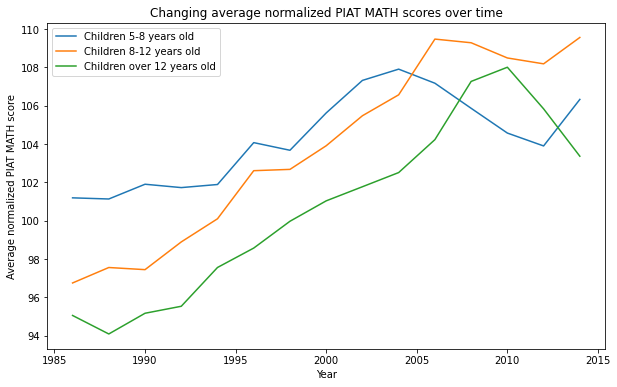

In [133]:
avgs_reset = piat_math_averages.reset_index()

# Group the data by the 'AGECH' level
grouped = avgs_reset.groupby('AGECH')

# Create a single subplot for all line plots
fig, ax = plt.subplots(figsize=(10, 6))

# Iterate over each group and plot the data on the same subplot
for age_group, group_df in grouped:
    ax.plot(group_df['year'], group_df['MATHZ'], label=age_group)

# Set labels and title
ax.set_xlabel('Year')
ax.set_ylabel('Average normalized PIAT MATH score')
ax.set_title('Changing average normalized PIAT MATH scores over time')

# Add a legend
ax.legend(labels=["Children 5-8 years old", "Children 8-12 years old", "Children over 12 years old"])

# Display the plot
plt.show()


In [134]:
'''
- Use pooled OLS that estimates "MATHZ" using only "AGECH" as the independent variable
(maybe only on the sample with 4 observations to limit selection bias) to show the increase
in mean MATHZ test scores.

- Alternatively, run a pooled regression using "year" as the independent variable with a full set of
controls, including "AGECH" and "YRB".
''' 

In [135]:
df_units["CRACE"].value_counts()

3.0    4161
2.0    2681
1.0    1775
Name: CRACE, dtype: int64

In [144]:
df_units["CRACE"].value_counts() / np.sum(df_units["CRACE"].value_counts())

3.0    0.482883
2.0    0.311129
1.0    0.205988
Name: CRACE, dtype: float64

In [145]:
df_2000["CPUBID"].value_counts().value_counts()

1    1179
2    1032
3     835
4     632
5      91
Name: CPUBID, dtype: int64

In [147]:
piat_df = pd.read_csv("output_files/df_missing_PIAT_vars.csv")
home_df = pd.read_csv("output_files/df_missing_HOME_vars.csv")

In [152]:
piat_df["year"].value_counts() / (piat_df["year"].value_counts() + df["year"].value_counts())

1986    0.191822
1988    0.085214
1990    0.087043
1992    0.101190
1994    0.047850
1996    0.041390
1998    0.040918
2000    0.019144
2002    0.024745
2004    0.027795
2006    0.010334
2008    0.023837
2010    0.057096
2012    0.019943
2014    0.022599
Name: year, dtype: float64

In [153]:
home_df["year"].value_counts() / (home_df["year"].value_counts() + df["year"].value_counts())

1986    0.151444
1988    0.184729
1990    0.124619
1992    0.125038
1994    0.120108
1996    0.127774
1998    0.144903
2000    0.109739
2002    0.117260
2004    0.165429
2006    0.183607
2008    0.175455
2010    0.152493
2012    0.158924
2014    0.172249
Name: year, dtype: float64

In [158]:
df_unclean = pd.read_csv("output_files/df_trimmed_for_age.csv", index_col=0)
df_unclean.head(10)

,CPUBID,MPUBID,CRACE,CSEX,CMOB,CYRB,MATHZ,year,MATHP,MATH,...,RECOG,RECOGZ,RECOGP,HOMEZ,HOMEP,COGNZ,COGNP,EMOTZ,EMOTP,AGECH
7,801,8,3,2,3,1976,108,1986,71,48,...,55,116,86,126.4,96,125.2,95,114.7,84,120
8,802,8,3,1,5,1979,125,1986,95,41,...,22,101,53,110.9,77,106.0,66,111.9,79,81
44,5701,57,3,1,7,1979,131,1986,98,42,...,-3,-3,-3,103.1,58,106.0,66,98.2,45,80
65,8601,86,2,2,11,1977,108,1986,70,40,...,49,120,91,99.7,50,105.6,66,92.8,32,100
74,9601,96,3,2,10,1980,135,1986,99,25,...,22,135,99,126.0,96,119.4,90,123.1,94,65
150,18001,180,3,1,5,1978,112,1986,78,39,...,-3,-3,-3,122.2,93,123.4,94,111.6,79,95
171,20501,205,1,2,8,1978,95,1986,38,23,...,23,94,35,104.2,61,104.3,61,-0.3,-3,91
174,20801,208,3,2,8,1975,82,1986,11,37,...,41,92,29,101.1,53,-0.3,-3,108.0,70,128
183,22401,224,2,1,12,1974,101,1986,53,48,...,58,112,78,102.3,55,95.3,37,108.0,70,136
184,22402,224,2,2,12,1977,122,1986,93,48,...,48,118,89,99.7,50,93.5,34,106.2,66,99


In [159]:
df_unclean["CPUBID"].value_counts().value_counts()

4    4567
3    1650
5    1531
2    1005
1     682
6       2
Name: CPUBID, dtype: int64

In [160]:
df_unclean[df_unclean["year"] >= 2000]["CPUBID"].value_counts().value_counts()

4    1158
1    1029
2     961
3     875
5     292
Name: CPUBID, dtype: int64

In [161]:
df_2000["CPUBID"].value_counts().value_counts()

1    1179
2    1032
3     835
4     632
5      91
Name: CPUBID, dtype: int64

In [172]:
df_moved_vals = df_2000.groupby("CPUBID").mean()["MOVED"]
df_moved_vals = df_moved_vals.reset_index()
no_move_units = list(df_moved_vals[df_moved_vals["MOVED"] == 0]["CPUBID"])

In [175]:
df_2000_no_move = df_2000.loc[df_2000["CPUBID"].isin(no_move_units)]
df_2000_no_move.head()

,CPUBID,MPUBID,CRACE,CSEX,CMOB,CYRB,MATHZ,year,MATHP,MATH,...,COGNP,EMOTZ,EMOTP,AGECH,AFQTP,TNFI,DIVORCE,MOVED,NUM_CHILDREN,STYPE
0,201,2,3,2,3,1993,100,2000,49,24,...,66,118.9,90,87,9,45000.0,0,0,2,1
1,303,3,3,2,4,1986,74,2000,4,40,...,66,104.4,61,171,46,64000.0,0,0,3,1
2,1601,16,3,1,2,1990,111,2000,77,51,...,66,104.4,61,124,57,81200.0,0,0,3,3
3,2001,20,3,2,8,1990,114,2000,83,52,...,91,112.7,81,120,63,96400.0,0,0,1,1
4,2501,25,3,1,10,1990,104,2000,60,44,...,53,119.0,90,114,57,332808.0,0,0,2,1


In [176]:
df_2000_no_move.shape

(4995, 29)

In [177]:
df_2000_no_move["CPUBID"].value_counts().value_counts()

1    806
2    604
3    432
4    345
5     61
Name: CPUBID, dtype: int64

In [178]:
df_2000_clean = df_2000_no_move[df_2000_no_move["STYPE"] == 1]

In [179]:
df_2000_clean["CPUBID"].value_counts().value_counts()

1    758
2    532
3    353
4    256
5     31
Name: CPUBID, dtype: int64

In [181]:
df_2000_clean.to_csv("output_files/df_2000_clean.csv")

In [182]:
ar1 = [-1,0,1]
ar2 = [-2,0,2]

In [189]:
child1 = [0,-1,-2,-3,-4,-5]
child2 = [0,1,2,3,4,5]
child3 = [0,0,0,0,0,0]
data = np.array([child1,child2,child3])


In [190]:
data

array([[ 0, -1, -2, -3, -4, -5],
       [ 0,  1,  2,  3,  4,  5],
       [ 0,  0,  0,  0,  0,  0]])

In [195]:
(data - np.mean(data, axis=0)) / np.std(data, axis=0)

C:\Users\19175\AppData\Local\Temp\ipykernel_22588\1285669241.py:1: RuntimeWarning: invalid value encountered in true_divide
  (data - np.mean(data, axis=0)) / np.std(data, axis=0)


array([[        nan, -1.22474487, -1.22474487, -1.22474487, -1.22474487,
        -1.22474487],
       [        nan,  1.22474487,  1.22474487,  1.22474487,  1.22474487,
         1.22474487],
       [        nan,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ]])

: 